# 6.2 — Superfície de Resposta: x_CH3OH em função de (RRC1, BRC1)

Grade 200×200 sobre o par de inputs com maior frac_interação para x_CH3OH identificado na Etapa 4.4:
- **RRC1** — razão de refluxo da coluna 1
- **BRC1** — razão de boil-up da coluna 1 (frac_interação > 0.30 para x_CH3OH segundo E4.4)

Os demais 4 inputs do conjunto S₆ = {T1, RRC1, BRC1, RRC2, BRC2, RFF} são fixados na média da faixa física (D-E6-02, D-E6-05).  
Nenhum modelo novo é treinado — toda computação é avaliação do surrogate SVR k*=6 serializado na Etapa 3.

## Seção 1 — Imports e Carga dos Modelos

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

BASE_E3  = "../../ETAPA_3/3.3_REDUZIDO/SVR"
BASE_E0  = "../../ETAPA_0/processed"
BASE_OUT = "."  # ARTEFATOS/ETAPA_6/6.2/

# Modelo SVR k*=6 para x_CH3OH
model_x = joblib.load(f"{BASE_E3}/x_CH3OH/k6/model.pkl")

# Scalers de X (8 features originais)
scaler_min   = np.load(f"{BASE_E0}/scaler_X_min.npy")    # shape (8,)
scaler_scale = np.load(f"{BASE_E0}/scaler_X_scale.npy")  # shape (8,)

# Scalers de y — ordem das colunas: [M_CH3OH=0, x_CH3OH=1, ET=2]
scaler_y_min   = np.load(f"{BASE_E0}/scaler_y_min.npy")    # shape (3,)
scaler_y_scale = np.load(f"{BASE_E0}/scaler_y_scale.npy")  # shape (3,)

# Índices de S_6 no vetor de 8 features: [T1, RRC1, BRC1, RRC2, BRC2, RFF]
# Colunas em X: ['P1', 'T1', 'T2', 'RRC1', 'BRC1', 'RRC2', 'BRC2', 'RFF']
#                  0     1    2      3       4       5       6       7
S6_IDX = [1, 3, 4, 5, 6, 7]  # T1, RRC1, BRC1, RRC2, BRC2, RFF

scaler_min_S6   = scaler_min[S6_IDX]
scaler_scale_S6 = scaler_scale[S6_IDX]

# Dataset de teste — overlay nos mapas de contorno (valores físicos)
# Colunas raw: [P1, T1, T2, RRC1, BRC1, RRC2, BRC2, RFF] — índices 3=RRC1, 4=BRC1
X_test_raw = np.load(f"{BASE_E0}/X_test_raw.npy")  # shape (193, 8)
RRC1_test  = X_test_raw[:, 3]
BRC1_test  = X_test_raw[:, 4]

print("Modelo carregado:", type(model_x).__name__)
print("scaler_min_S6  :", scaler_min_S6)
print("scaler_scale_S6:", scaler_scale_S6)
print("scaler_y_min[1] (x_CH3OH)  :", scaler_y_min[1])
print("scaler_y_scale[1] (x_CH3OH):", scaler_y_scale[1])
print("X_test_raw shape:", X_test_raw.shape)


Modelo carregado: SVR
scaler_min_S6  : [2.00119416e+02 1.00675628e+00 5.02164445e-01 1.00059745e+00
 5.01838760e-01 1.00071268e-02]
scaler_scale_S6: [99.84375386  8.9864509   9.49155418  8.99763685  9.49631006  0.23988401]
scaler_y_min[1] (x_CH3OH)  : 0.638649919275767
scaler_y_scale[1] (x_CH3OH): 0.3596182156463881
X_test_raw shape: (193, 8)


## Seção 2 — Definição da Grade 200×200

In [8]:
# Faixas físicas dos inputs varridos
rrc1_grid = np.linspace(1.0,  10.0, 200)
brc1_grid = np.linspace(0.5,  10.0, 200)

# Meshgrid — convenção: RRC1 no eixo x (colunas), BRC1 no eixo y (linhas)
RRC1_mesh, BRC1_mesh = np.meshgrid(rrc1_grid, brc1_grid)  # shape (200, 200) cada

# Valores fixos (média da faixa física) para os outros 4 inputs de S_6 (D-E6-02, D-E6-05)
# Ordem S_6: [T1, RRC1, BRC1, RRC2, BRC2, RFF]
T1_fixed   = (200 + 300) / 2    # = 250.0 °C
RRC2_fixed = (1   + 10 ) / 2    # =   5.5
BRC2_fixed = (0.5 + 10 ) / 2    # =   5.25
RFF_fixed  = (0.01 + 0.25) / 2  # =   0.13

N = 200 * 200  # = 40.000 pontos

X_grid = np.column_stack([
    np.full(N, T1_fixed),    # T1
    RRC1_mesh.ravel(),       # RRC1
    BRC1_mesh.ravel(),       # BRC1
    np.full(N, RRC2_fixed),  # RRC2
    np.full(N, BRC2_fixed),  # BRC2
    np.full(N, RFF_fixed),   # RFF
])  # shape (40000, 6)

# Normalização min-max com escalares de S_6
X_grid_norm = (X_grid - scaler_min_S6) / scaler_scale_S6

print(f"Grade: {X_grid.shape} | Normalizada: {X_grid_norm.shape}")
print(f"Inputs fixos — T1={T1_fixed}, RRC2={RRC2_fixed}, BRC2={BRC2_fixed}, RFF={RFF_fixed}")

Grade: (40000, 6) | Normalizada: (40000, 6)
Inputs fixos — T1=250.0, RRC2=5.5, BRC2=5.25, RFF=0.13


## Seção 3 — Predição do Surrogate

In [9]:
# Predição em espaço normalizado — modelo foi treinado com y normalizado
x_norm = model_x.predict(X_grid_norm).reshape(200, 200)

# Desnormalização para fração mássica
# Ordem de y: [M_CH3OH=0, x_CH3OH=1, ET=2]
x_pred = x_norm * scaler_y_scale[1] + scaler_y_min[1]  # fração mássica [0, 1]

print("x_CH3OH — min:", x_pred.min().round(4), "| max:", x_pred.max().round(4), "| NaN:", np.isnan(x_pred).sum())
print("Faixa esperada: [0, 1] (fração mássica)")
if x_pred.min() < 0 or x_pred.max() > 1:
    print("AVISO: predições fora de [0, 1] — verificar escaler ou extrapolação do surrogate")
else:
    print("OK — predições dentro de [0, 1]")

x_CH3OH — min: 0.6899 | max: 1.0096 | NaN: 0
Faixa esperada: [0, 1] (fração mássica)
AVISO: predições fora de [0, 1] — verificar escaler ou extrapolação do surrogate


## Seção 4 — Visualizações

### 4.1 — Superfície 3D: x_CH3OH

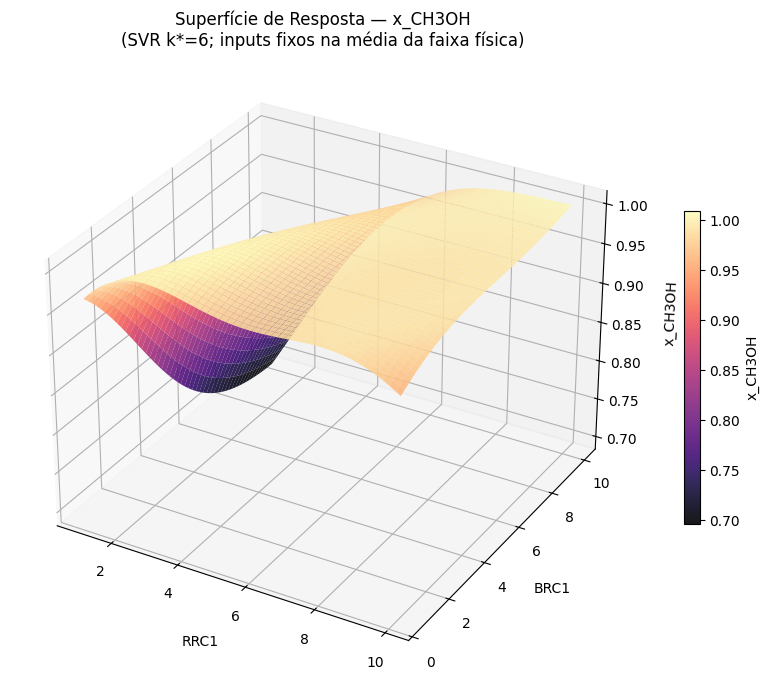

Salvo: 6.2_sr_xCH3OH_RRC1_BRC1_3d.png


In [10]:
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    RRC1_mesh, BRC1_mesh, x_pred,
    cmap='magma', linewidth=0, antialiased=True, alpha=0.9
)
fig.colorbar(surf, ax=ax, shrink=0.5, label='x_CH3OH')

ax.set_xlabel('RRC1', labelpad=10)
ax.set_ylabel('BRC1', labelpad=10)
ax.set_zlabel('x_CH3OH', labelpad=10)
ax.set_title('Superfície de Resposta — x_CH3OH\n(SVR k*=6; inputs fixos na média da faixa física)')

plt.tight_layout()
plt.savefig(f"{BASE_OUT}/6.2_sr_xCH3OH_RRC1_BRC1_3d.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: 6.2_sr_xCH3OH_RRC1_BRC1_3d.png")

### 4.2 — Mapa de Contorno: x_CH3OH (com linha de pureza e overlay do dataset original)

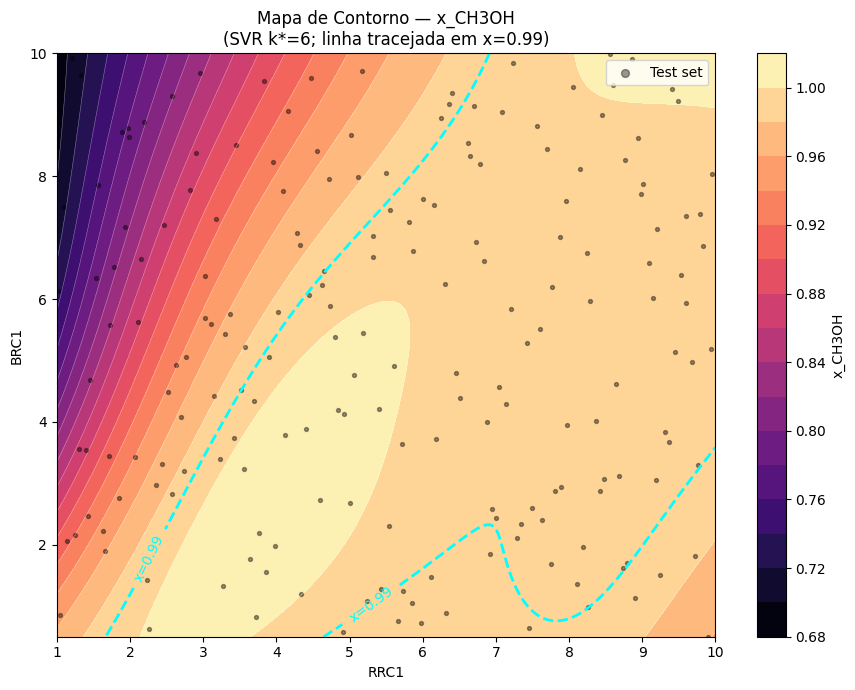

Salvo: 6.2_sr_xCH3OH_RRC1_BRC1_contorno.png


In [20]:
thr = 0.99

fig, ax = plt.subplots(figsize=(9, 7))

cf = ax.contourf(RRC1_mesh, BRC1_mesh, x_pred, levels=20, cmap='magma')
fig.colorbar(cf, ax=ax, label='x_CH3OH')
ax.contour(RRC1_mesh, BRC1_mesh, x_pred, levels=20, colors='white', linewidths=0.4, alpha=0.4)

# Linha de restrição de pureza x_CH3OH (referência para 6.3)
cs = ax.contour(
    RRC1_mesh, BRC1_mesh, x_pred,
    levels=[thr], colors=['cyan'], linewidths=2.0, linestyles='--'
)
ax.clabel(cs, fmt={thr: f'x={thr}'}, fontsize=10, colors='cyan')

# Overlay dos pontos do test set
ax.scatter(RRC1_test, BRC1_test, c='black', s=8, alpha=0.4, label='Test set')

ax.set_xlabel('RRC1')
ax.set_ylabel('BRC1')
ax.set_title(f'Mapa de Contorno — x_CH3OH\n(SVR k*=6; linha tracejada em x={thr})')
ax.legend(loc='upper right', markerscale=2)

plt.tight_layout()
plt.savefig(f"{BASE_OUT}/6.2_sr_xCH3OH_RRC1_BRC1_contorno.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: 6.2_sr_xCH3OH_RRC1_BRC1_contorno.png")

## Seção 5 — Interpretação

### Coerência com frac_interação de Sobol (Etapa 4.4)

A Etapa 4.4 identificou para **x_CH3OH** uma frac_interação de BRC1 superior a 0.30, indicando que mais de 30% do efeito total de BRC1 sobre a pureza é mediado por interações com outros inputs — em particular com RRC1 (acoplamento coluna 1). Esse acoplamento foi o critério para a seleção do par (RRC1, BRC1) nesta sub-etapa (D-E6-04).

**Padrão esperado na superfície:**  
Uma superfície com curvatura pronunciada ou formato de sela no espaço (RRC1 × BRC1) é consistente com frac_interação elevada — isocurvas curvas ou convergentes indicam que o efeito de RRC1 sobre x_CH3OH depende do valor de BRC1 (e vice-versa). Se as isocurvas fossem retas e paralelas, o sistema seria aditivo puro (sem interação), o que contradiz os índices de Sobol.

**Referência para 6.3:**  
A linha de contorno em x_CH3OH = 0.98 no mapa delimita a região do espaço (RRC1, BRC1) onde a restrição de pureza da Etapa 6.3 é satisfeita. Pares (RRC1, BRC1) acima dessa linha (maior pureza) serão candidatos viáveis na fronteira de Pareto, enquanto pares abaixo serão descartados pelo filtro x_CH3OH ≥ 0.98.

**Decisões:**  
- D-E6-04: par (RRC1, BRC1) justificado pela maior frac_interação Sobol para x_CH3OH (E4.4).  
- D-E6-05: RFF fixado em 0.13 (média de [0.01, 0.25]) — mantém comparabilidade entre superfícies das três sub-etapas.

## Seção 6 — Validação

In [21]:
import os

artefatos = [
    "6.2_sr_xCH3OH_RRC1_BRC1_3d.png",
    "6.2_sr_xCH3OH_RRC1_BRC1_contorno.png",
]

print("=== Validação 6.2 ===")
for f in artefatos:
    exists = os.path.isfile(f"{BASE_OUT}/{f}")
    print(f"  {'OK' if exists else 'FALTA'} — {f}")

print(f"\nGrid shape   : {X_grid.shape}  (esperado: (40000, 6))")
print(f"NaN x_CH3OH  : {np.isnan(x_pred).sum()}  (esperado: 0)")
print(f"x_CH3OH range: [{x_pred.min():.4f}, {x_pred.max():.4f}]  (esperado: subconjunto de [0, 1])")
print(f"Overlay test : {len(X_test_raw)} pontos disponíveis")

# Verificar que existe região com x_pred >= 0.98 (necessário para 6.3)
n_viavel = (x_pred >= thr).sum()
print(f"Pontos grade com x>={thr}: {n_viavel} de {N} ({100*n_viavel/N:.1f}%)")
if n_viavel == 0:
    print(f"AVISO: nenhum ponto da grade atinge x>={thr} — surrogate pode estar subestimando a pureza")
else:
    print("OK — região viável identificada na grade")

=== Validação 6.2 ===
  OK — 6.2_sr_xCH3OH_RRC1_BRC1_3d.png
  OK — 6.2_sr_xCH3OH_RRC1_BRC1_contorno.png

Grid shape   : (40000, 6)  (esperado: (40000, 6))
NaN x_CH3OH  : 0  (esperado: 0)
x_CH3OH range: [0.6899, 1.0096]  (esperado: subconjunto de [0, 1])
Overlay test : 193 pontos disponíveis
Pontos grade com x>=0.99: 23182 de 40000 (58.0%)
OK — região viável identificada na grade
